In [6]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# read in the CSV
#path = '/Volumes/disk1/Central Valley Fog/CV_rows.csv'
path = 'E:/Central Valley Fog/CV_rows.csv'

CV_rows = pd.read_csv(path, low_memory=False)

print(CV_rows)

              STATION  LATITUDE  LONGITUDE                 DATE  \
0         USW00093210  39.49000 -121.61833  2004-12-31 16:53:00   
1         USW00093210  39.49000 -121.61833  2004-12-31 17:38:00   
2         USW00093210  39.49000 -121.61833  2004-12-31 17:53:00   
3         USW00093210  39.49000 -121.61833  2004-12-31 18:26:00   
4         USW00093210  39.49000 -121.61833  2004-12-31 18:44:00   
...               ...       ...        ...                  ...   
12439215  USW00023167  36.73333 -119.81667  2025-12-31 14:35:00   
12439216  USW00023167  36.73333 -119.81667  2025-12-31 14:55:00   
12439217  USW00023167  36.73333 -119.81667  2025-12-31 15:15:00   
12439218  USW00023167  36.73333 -119.81667  2025-12-31 15:35:00   
12439219  USW00023167  36.73333 -119.81667  2025-12-31 15:55:00   

          HourlyPrecipitation  HourlyVisibility  \
0                         1.5            16.093   
1                         0.3            16.093   
2                         0.3            1

In [8]:
CV_rows = CV_rows.drop(columns="MonthlyNumberDaysWithHeavyFog")

print("CV_rows shape:", CV_rows.shape)

CV_rows shape: (12439220, 11)


In [ ]:
# convert hourly precipitation and visibility to numeric values (did this in cleaning file)
#CV_rows["HourlyPrecipitation"] = pd.to_numeric(CV_rows["HourlyPrecipitation"], errors='coerce')
#CV_rows["HourlyVisibility"] = pd.to_numeric(CV_rows["HourlyVisibility"], errors='coerce')

In [12]:
# remove rows where HourlyVisibility is zero or missing
CV_rows = CV_rows[CV_rows["HourlyVisibility"].gt(0)]

print("CV_rows:", CV_rows.shape)

CV_rows: (12363264, 11)


In [15]:
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (182963, 11)


In [16]:
CV_densefog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 0.403)
]

print("CV_densefog_rows:", CV_densefog_rows.shape)

CV_densefog_rows: (123759, 11)


In [17]:
threshold = pd.Timedelta(hours=1.5)

for df in (CV_fog_rows, CV_densefog_rows):
    df['DATE'] = pd.to_datetime(df['DATE'])
    df.sort_values(['STATION', 'DATE'], inplace=True)
    df['time_diff'] = df.groupby('STATION')['DATE'].diff()
    df['new_event'] = df['time_diff'] > threshold
    df['event_id'] = df.groupby('STATION')['new_event'].cumsum().astype(int)
    df['station_event_id'] = df['STATION'] + '_' + df['event_id'].astype(str)

CV_fog_events = (
    CV_fog_rows.groupby(['STATION', 'event_id'])
    .agg(
        start=('DATE', 'first'),
        end=('DATE', 'last'),
        records=('DATE', 'size')
    )
    .assign(
        duration_hours=lambda x: (x['end'] - x['start']) / pd.Timedelta(hours=1),
        fog_hours=lambda x: x['records']
    )
    .reset_index()
)

CV_densefog_events = (
    CV_densefog_rows.groupby(['STATION', 'event_id'])
    .agg(
        start=('DATE', 'first'),
        end=('DATE', 'last'),
        records=('DATE', 'size')
    )
    .assign(
        duration_hours=lambda x: (x['end'] - x['start']) / pd.Timedelta(hours=1),
        densefog_hours=lambda x: x['records']
    )
    .reset_index()
)

print("Fog events:", CV_fog_events.shape)
print("Dense fog events:", CV_densefog_events.shape)
print(CV_fog_events.head())
print(CV_densefog_events.head())

Fog events: (45494, 7)
Dense fog events: (36777, 7)
       STATION  event_id               start                 end  records  \
0  USW00000479         0 2014-11-13 09:55:00 2014-11-13 12:35:00        6   
1  USW00000479         1 2014-11-14 08:35:00 2014-11-14 08:35:00        1   
2  USW00000479         2 2014-11-21 21:15:00 2014-11-21 21:35:00        2   
3  USW00000479         3 2014-11-22 00:15:00 2014-11-22 00:15:00        1   
4  USW00000479         4 2014-11-22 22:15:00 2014-11-22 22:15:00        1   

   duration_hours  fog_hours  
0        2.666667          6  
1        0.000000          1  
2        0.333333          2  
3        0.000000          1  
4        0.000000          1  
       STATION  event_id               start                 end  records  \
0  USW00000479         0 2014-11-13 10:55:00 2014-11-13 10:55:00        1   
1  USW00000479         1 2014-11-13 12:35:00 2014-11-13 12:35:00        1   
2  USW00000479         2 2014-11-21 21:15:00 2014-11-21 21:15:00    

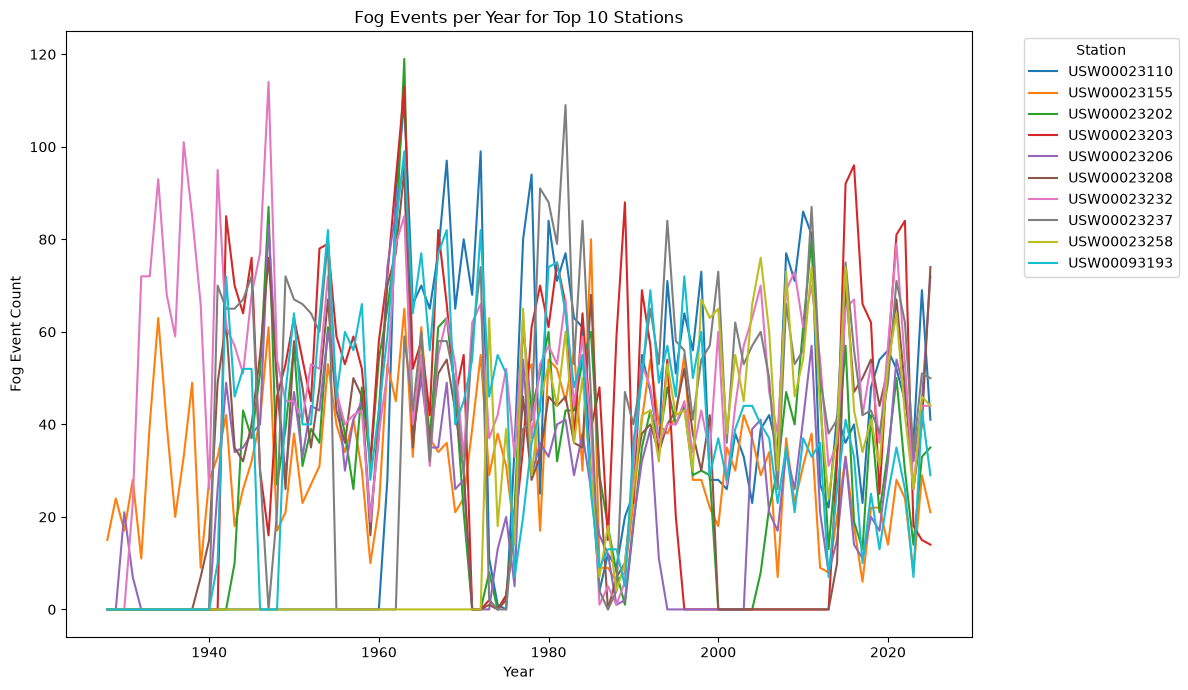

In [18]:
CV_fog_events['year'] = CV_fog_events['start'].dt.year

events_by_station_year = (
    CV_fog_events
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_event_count')
)

top_stations = (
    events_by_station_year
    .groupby('STATION')['fog_event_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = (
    events_by_station_year[events_by_station_year['STATION'].isin(top_stations)]
    .pivot(index='year', columns='STATION', values='fog_event_count')
    .fillna(0)
)

plot_df.plot(figsize=(12, 7))
plt.title('Fog Events per Year for Top 10 Stations')
plt.xlabel('Year')
plt.ylabel('Fog Event Count')
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

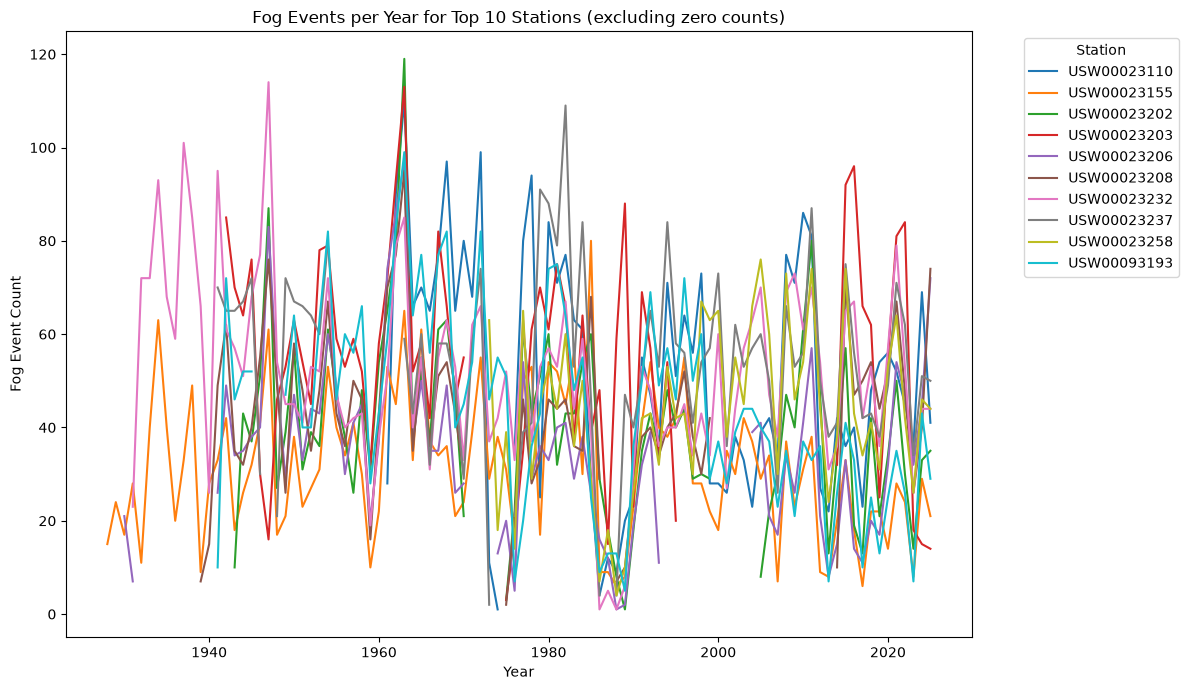

In [19]:
plot_df_nozeros = plot_df.replace(0, np.nan)

plot_df_nozeros.plot(figsize=(12, 7))
plt.title('Fog Events per Year for Top 10 Stations (excluding zero counts)')
plt.xlabel('Year')
plt.ylabel('Fog Event Count')
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_14308\763379612.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


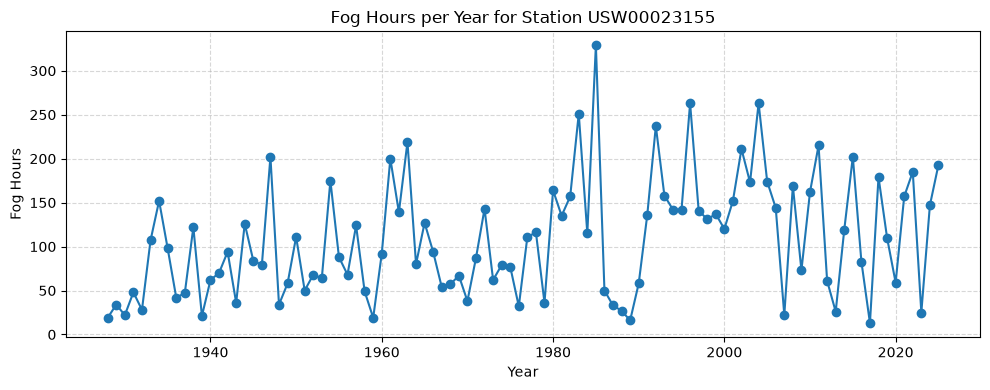

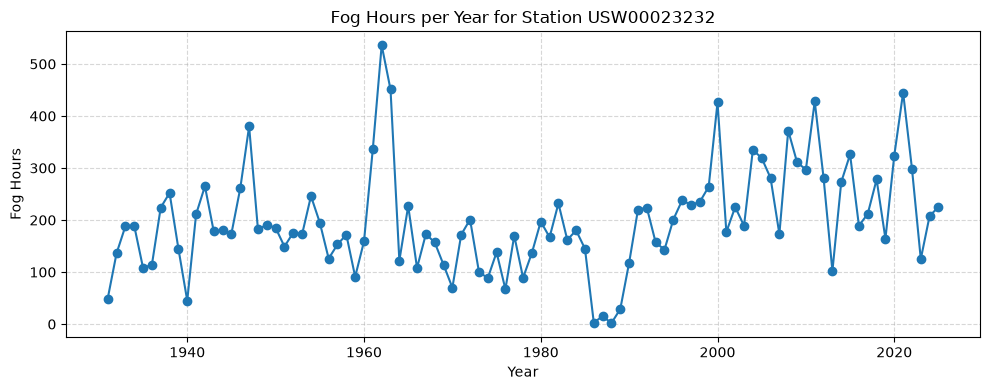

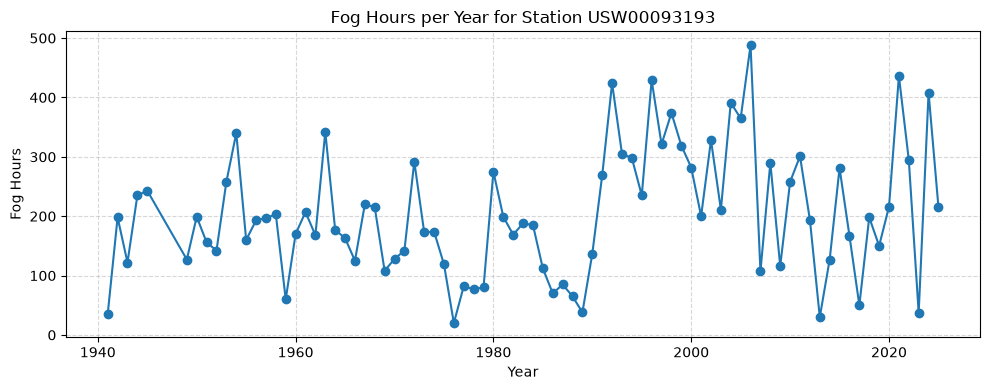

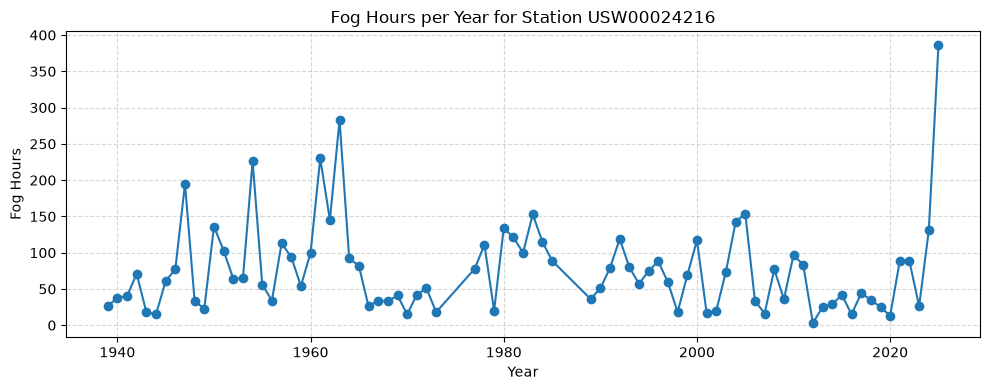

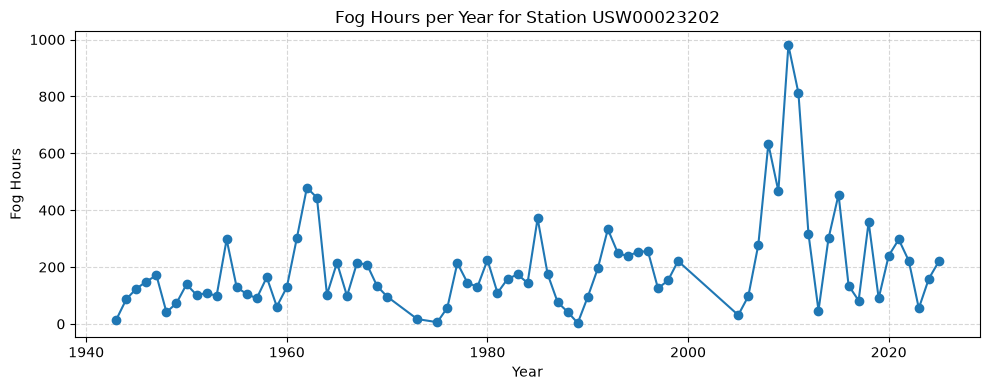

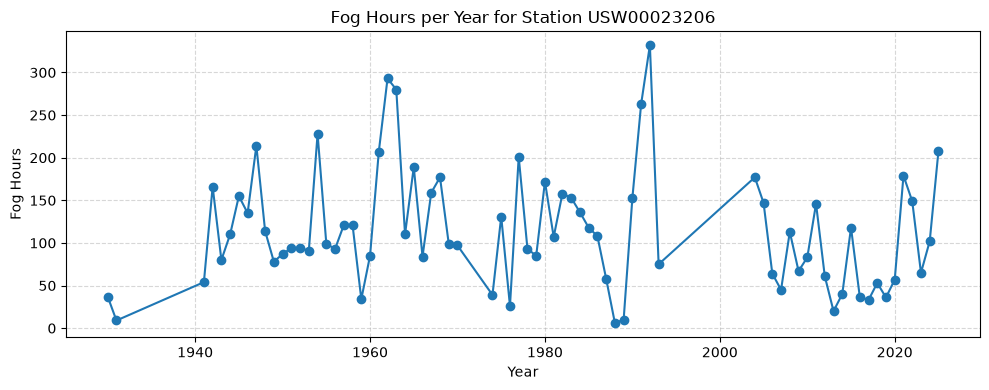

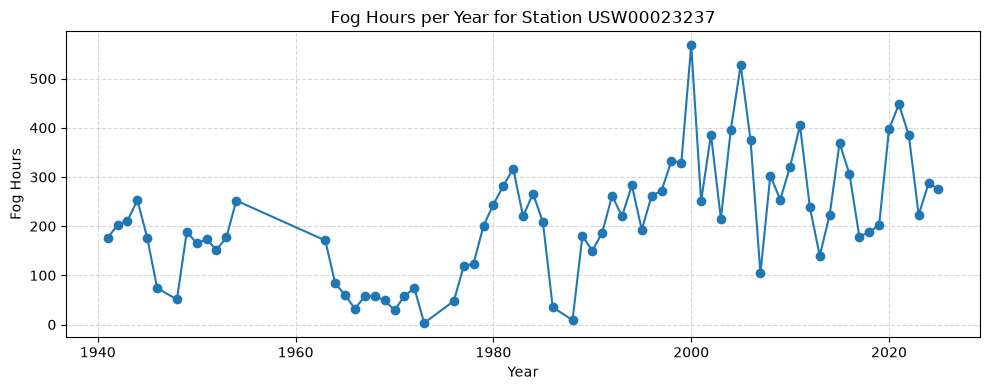

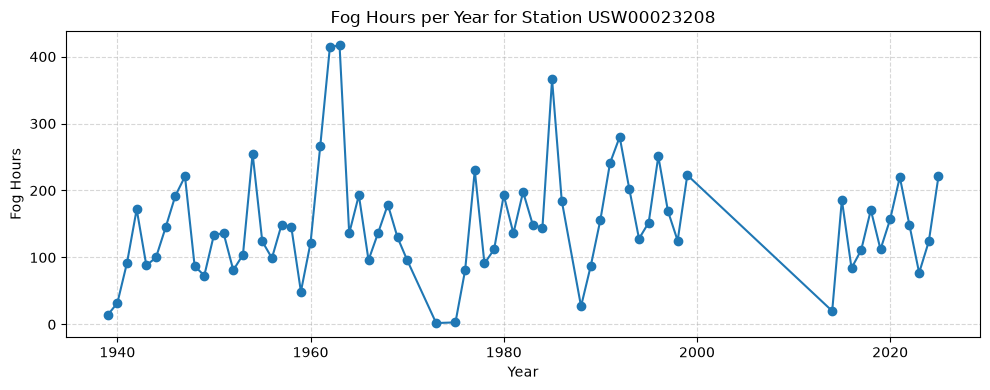

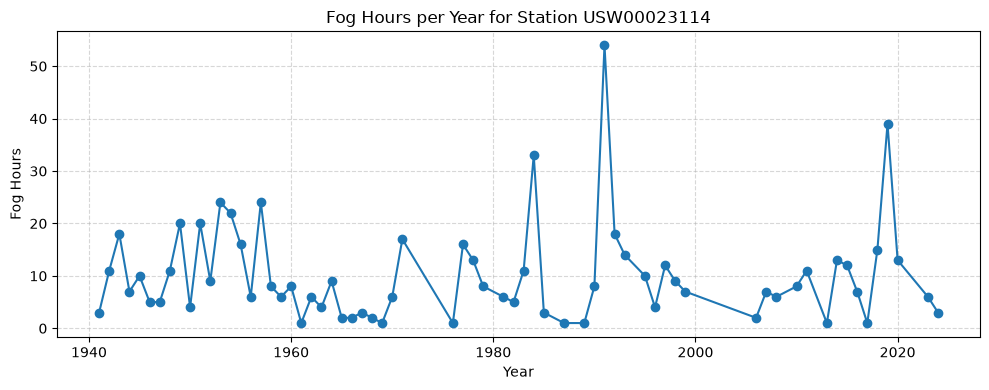

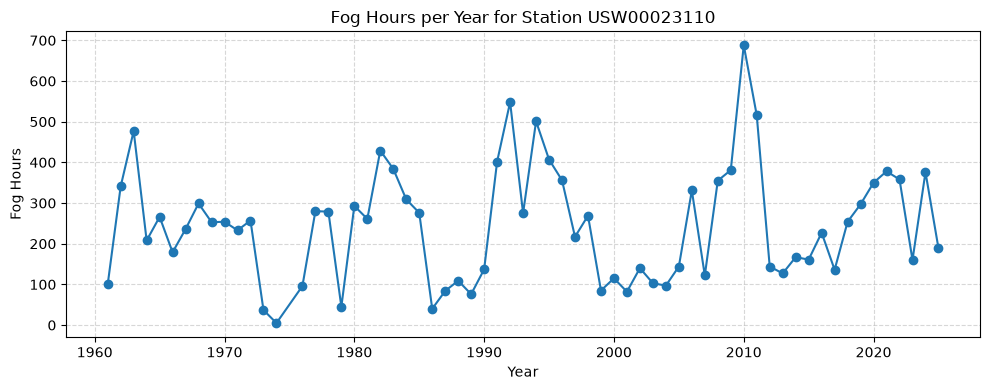

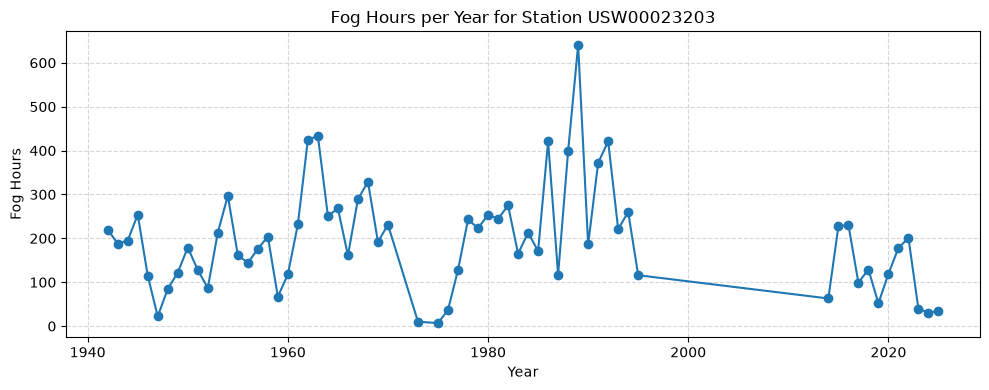

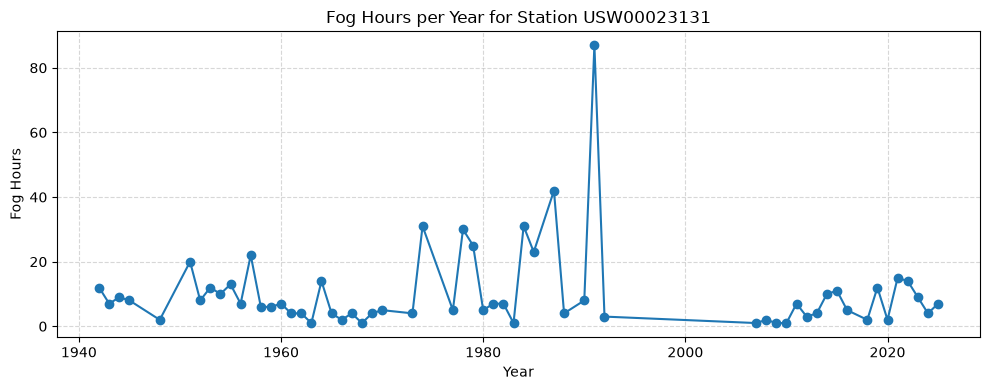

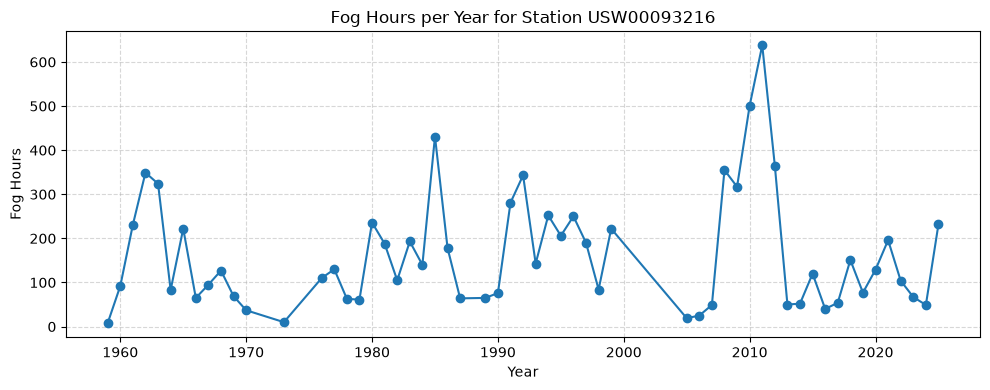

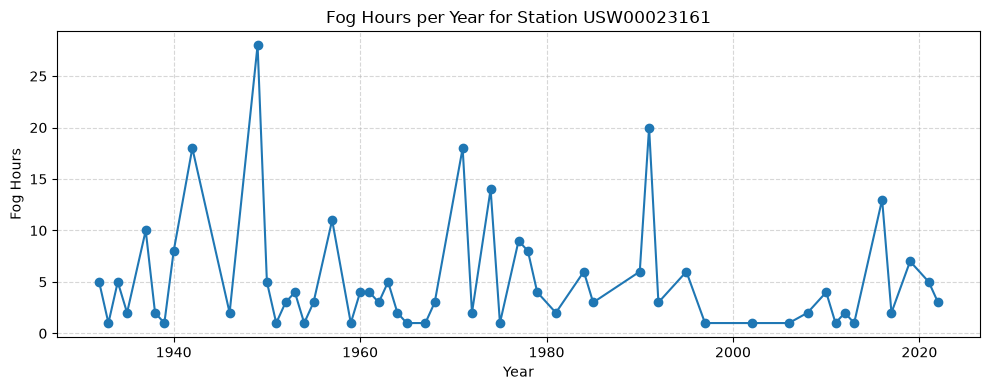

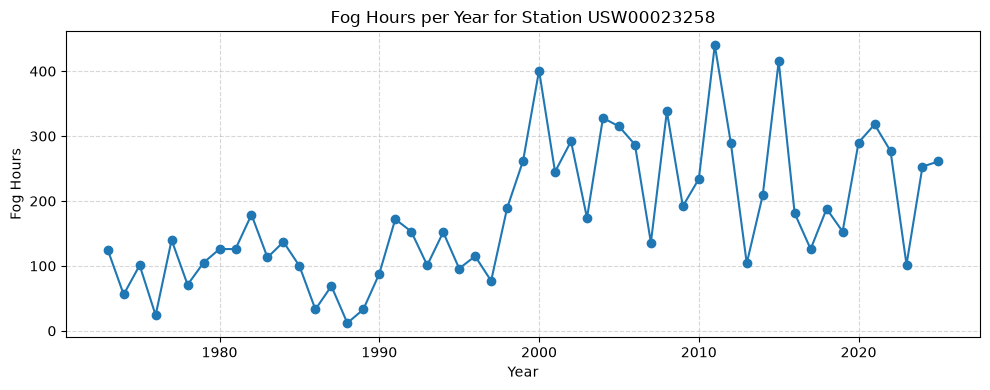

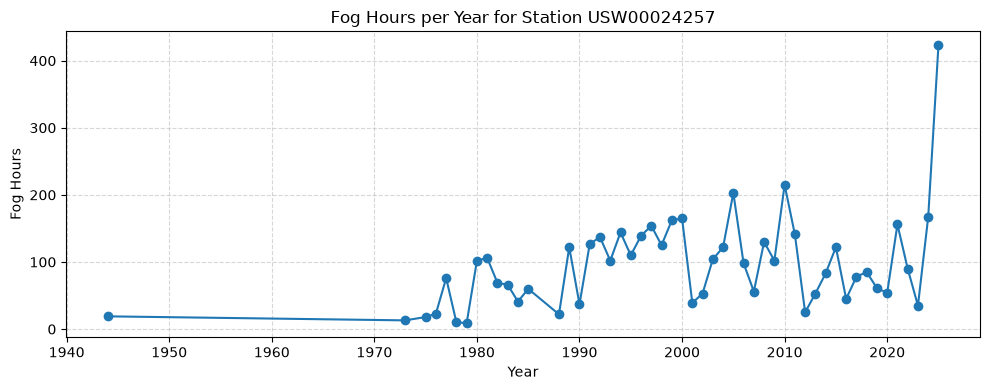

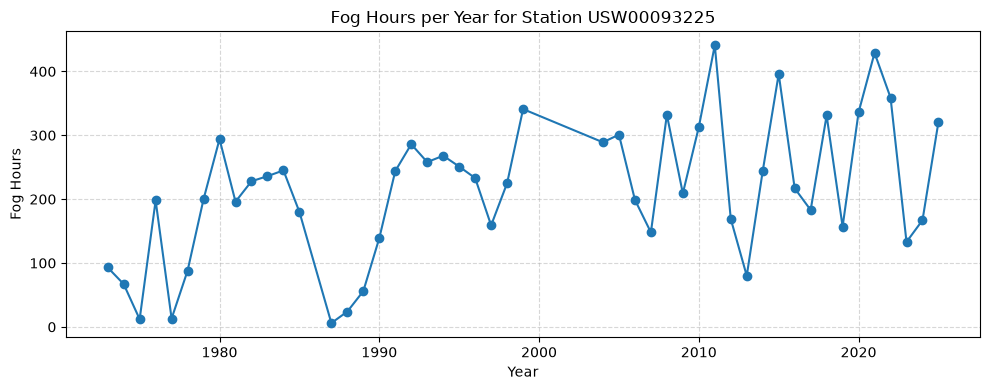

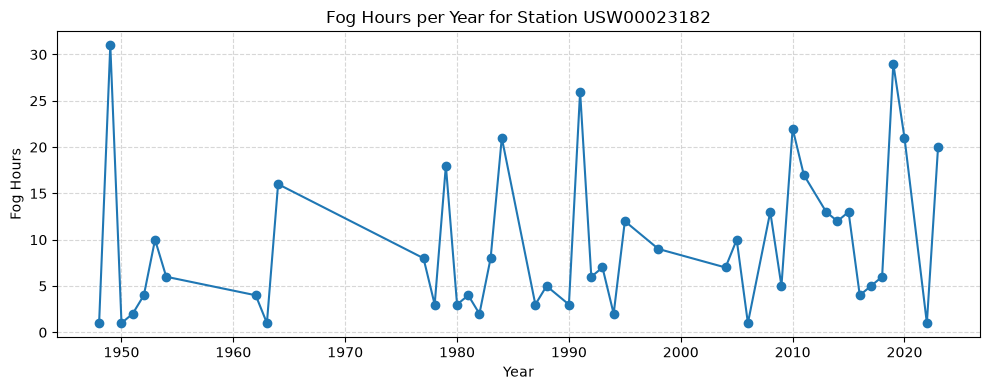

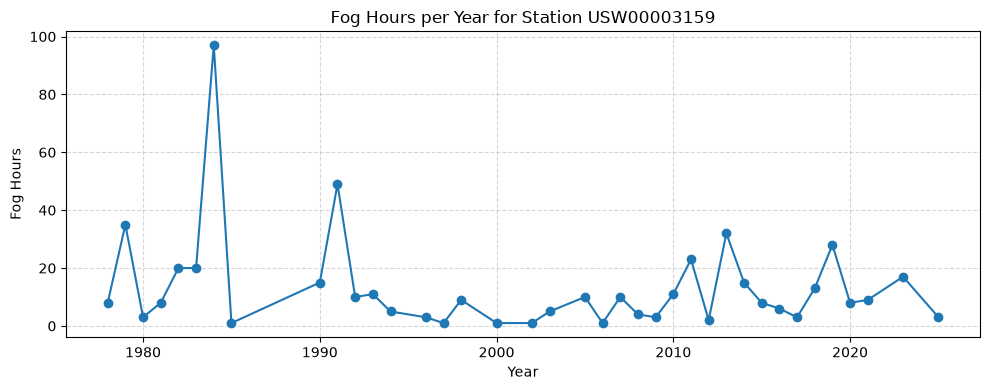

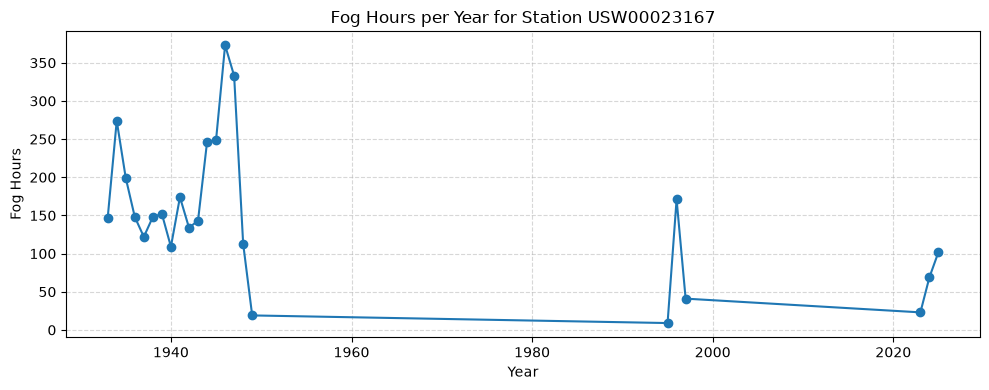

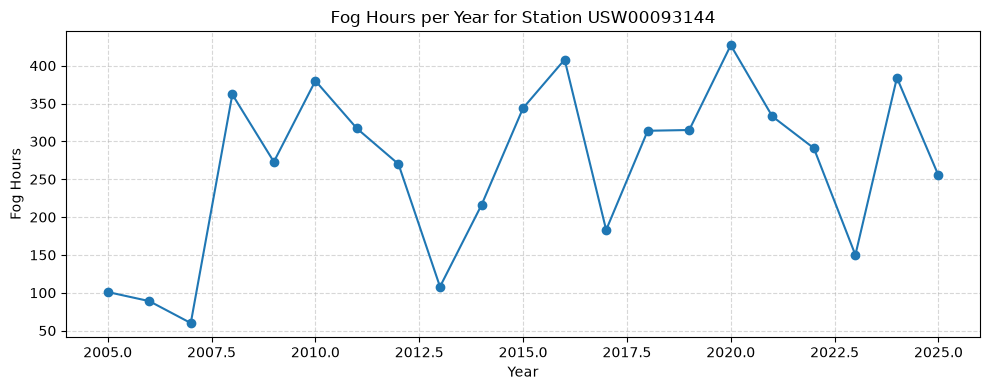

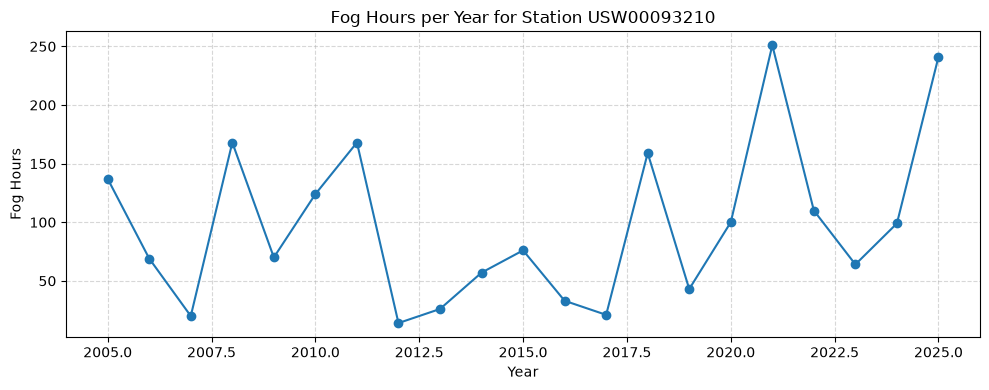

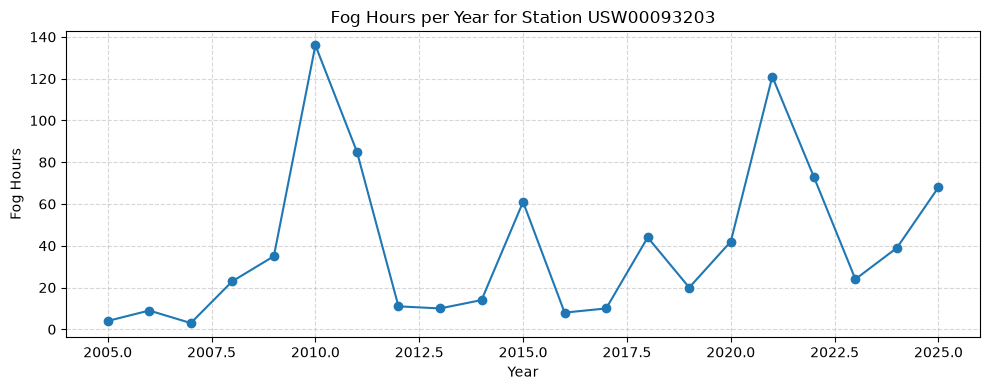

In [20]:
fog_hours_year = (
    CV_fog_rows
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='fog_hours')
)

station_year_counts = fog_hours_year.groupby('STATION')['year'].nunique()
long_term_stations = station_year_counts[station_year_counts > 20].sort_values(ascending=False).index

for station in long_term_stations:
    station_df = fog_hours_year[fog_hours_year['STATION'] == station].sort_values('year')
    plt.figure(figsize=(10, 4))
    plt.plot(station_df['year'], station_df['fog_hours'], marker='o', linestyle='-')
    plt.title(f'Fog Hours per Year for Station {station}')
    plt.xlabel('Year')
    plt.ylabel('Fog Hours')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_14308\4266023836.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4))


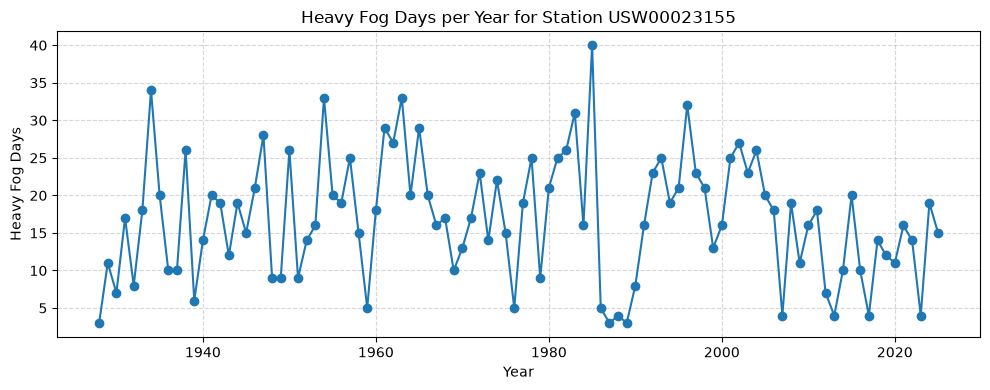

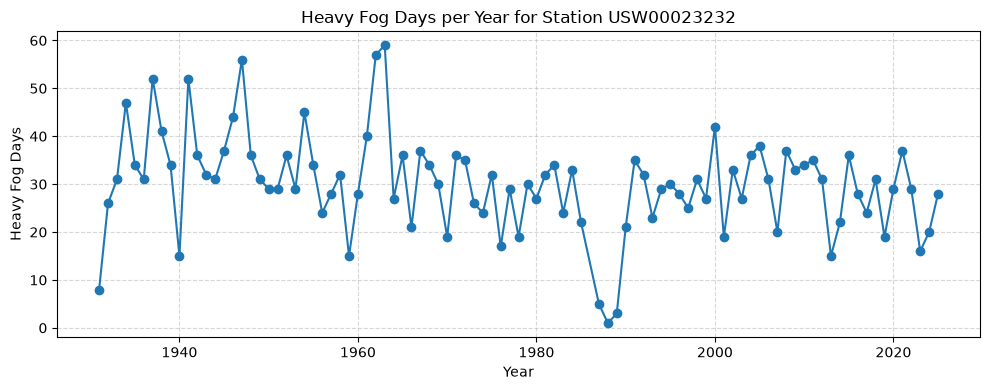

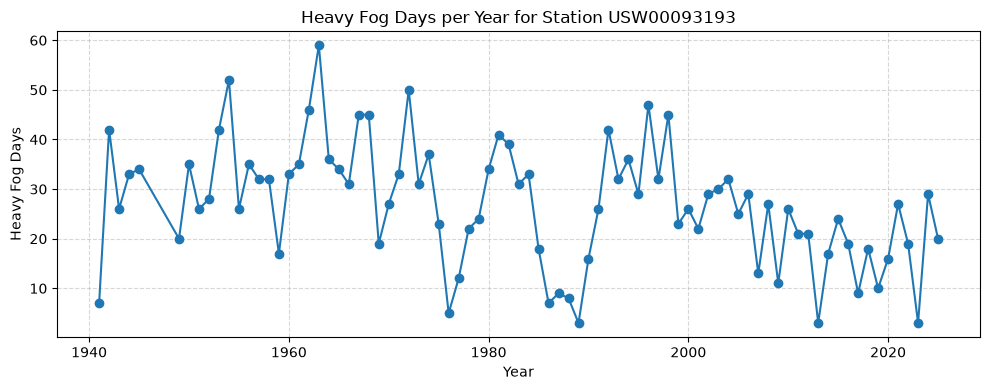

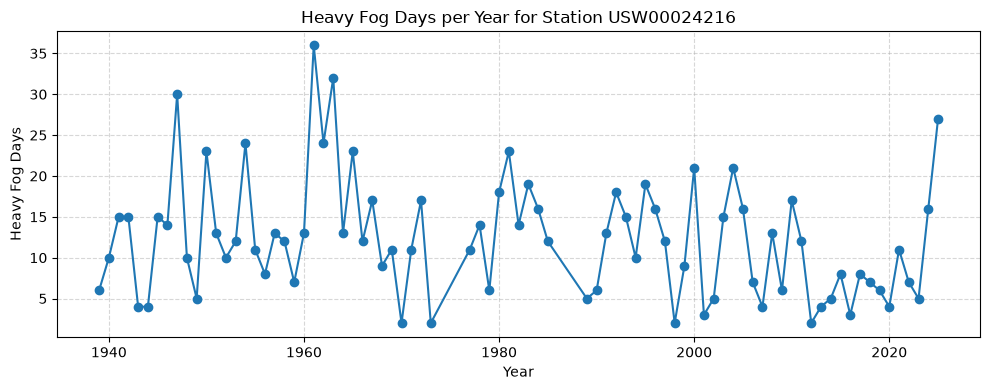

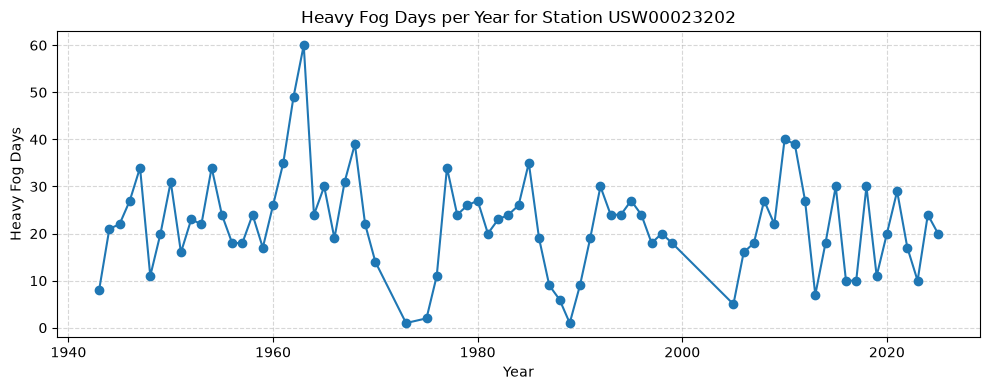

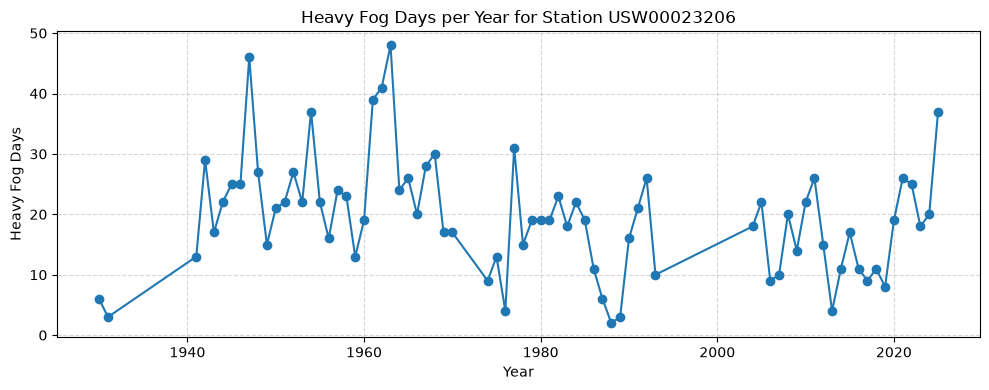

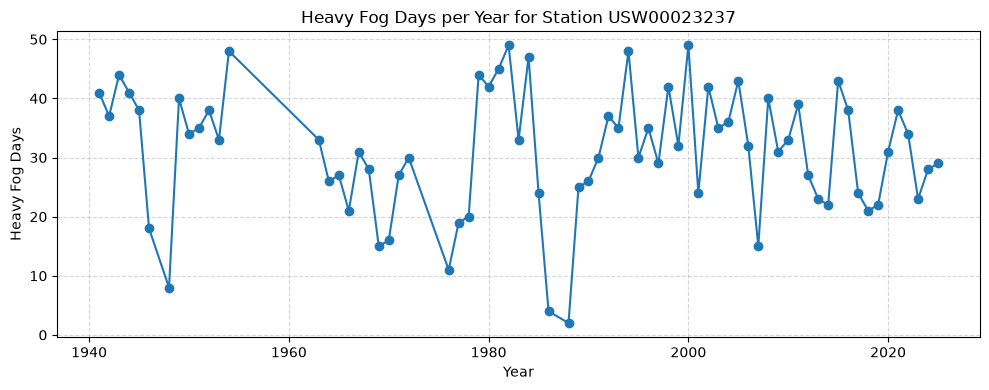

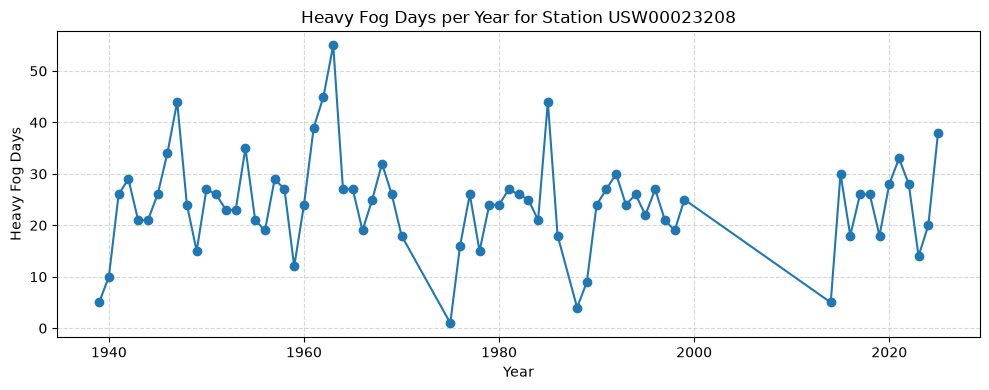

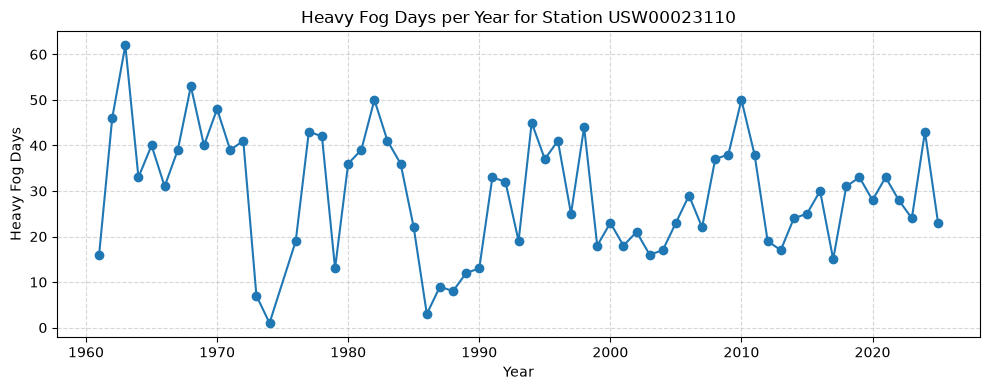

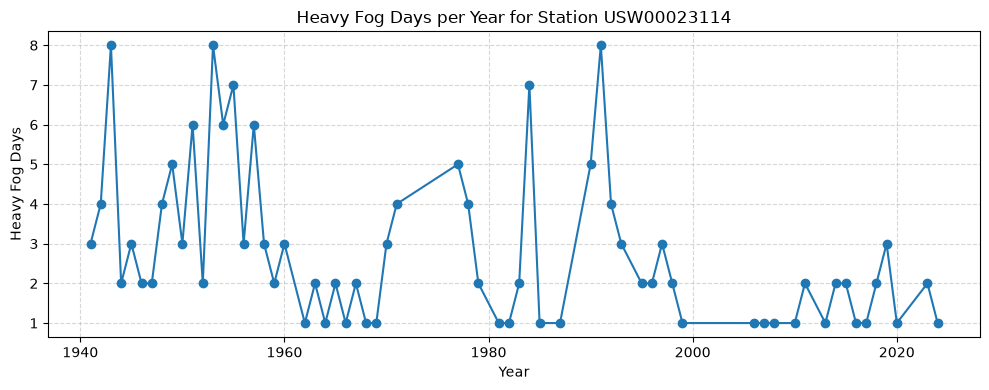

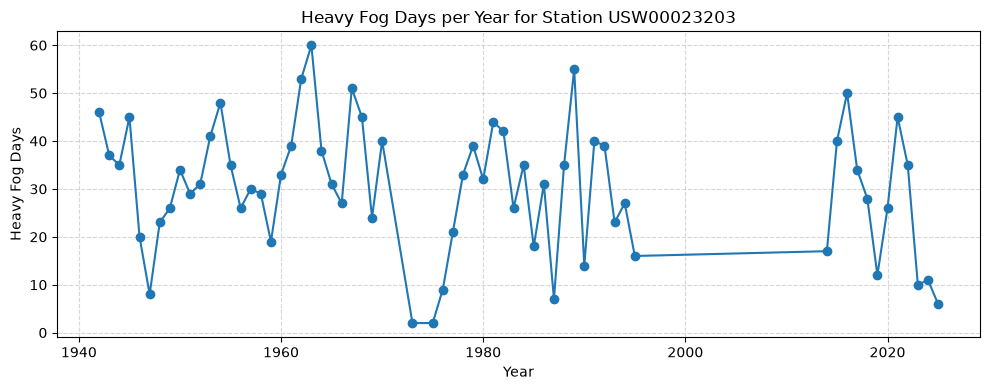

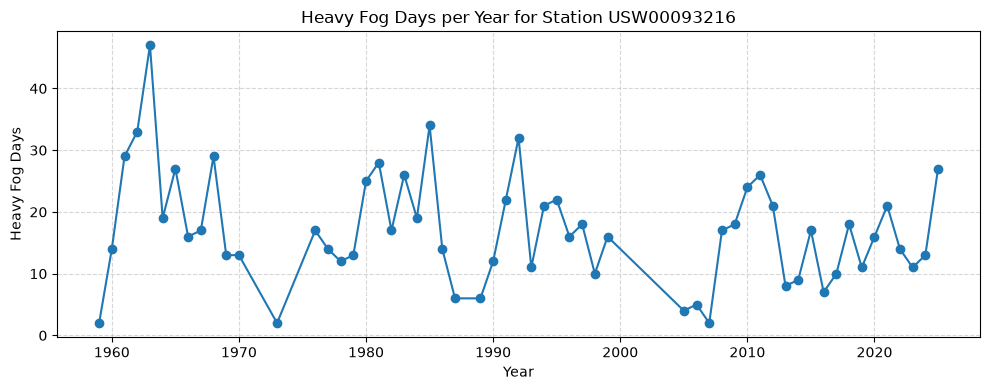

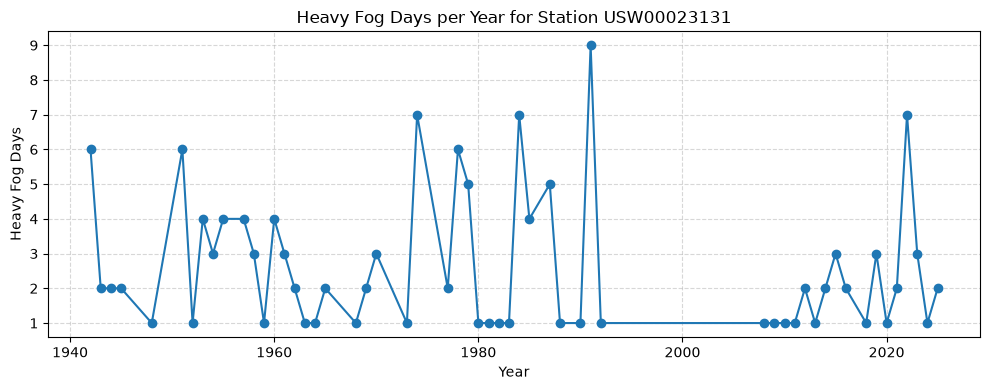

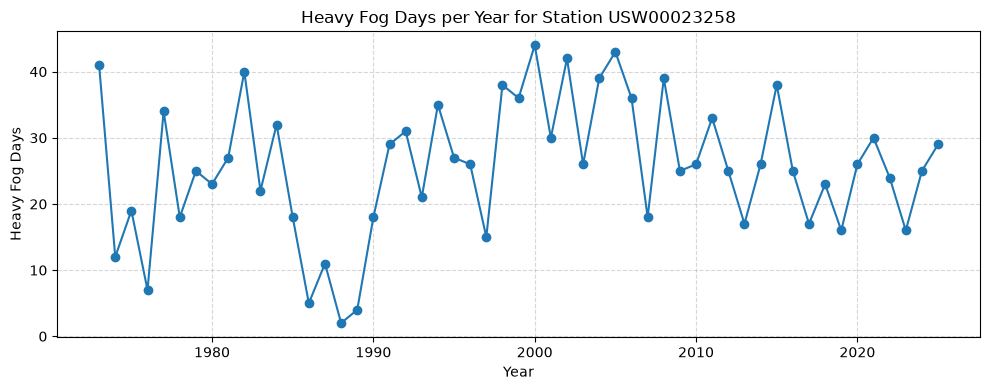

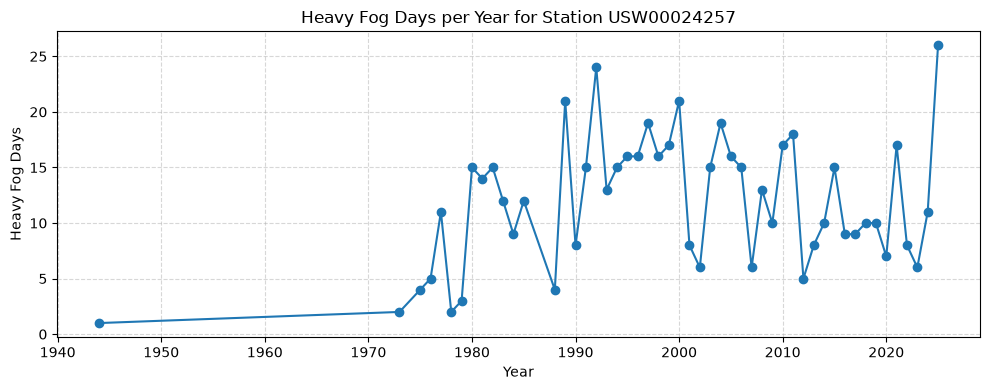

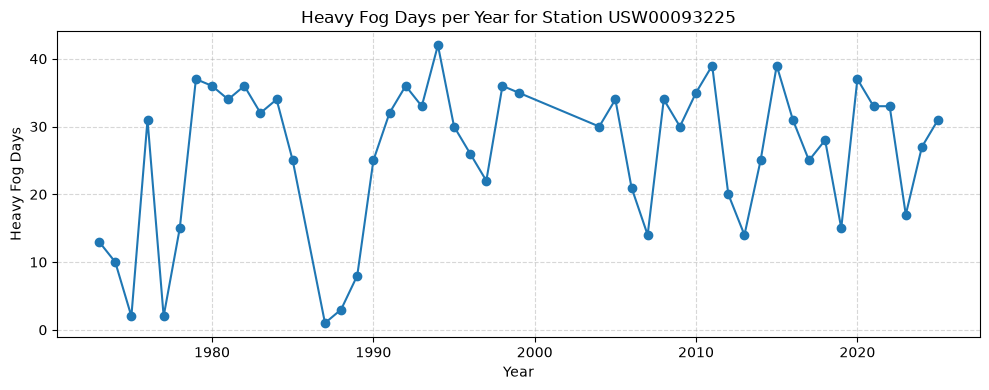

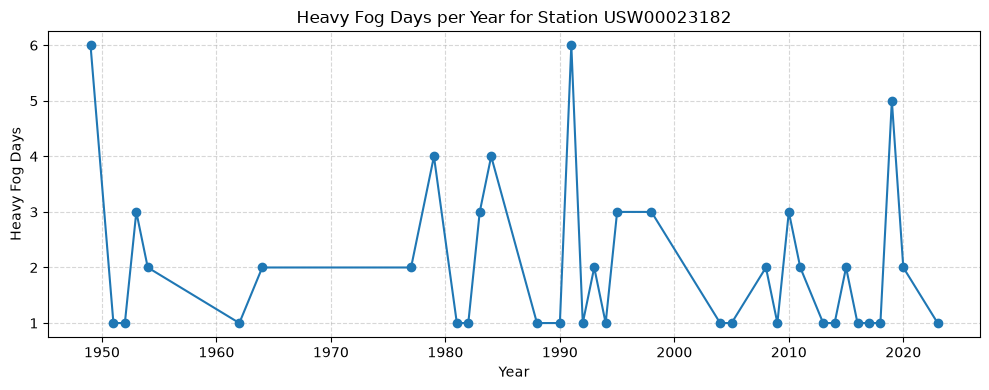

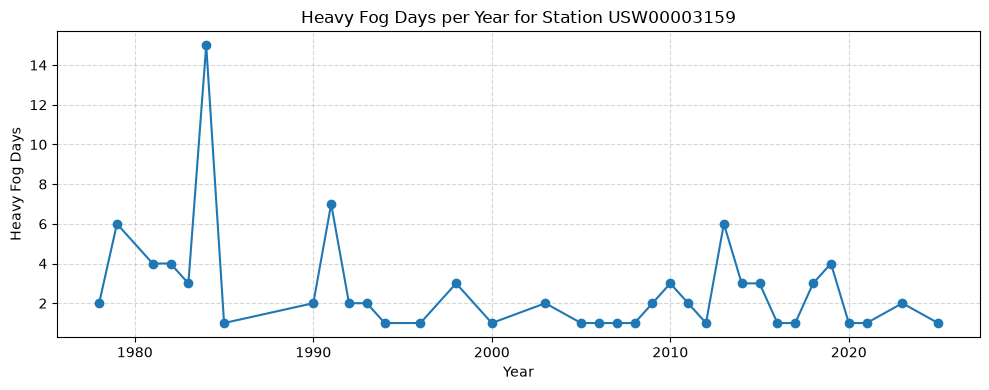

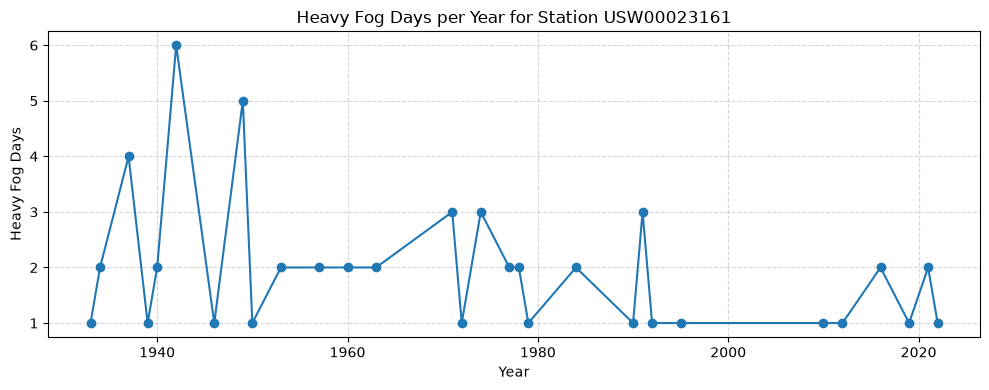

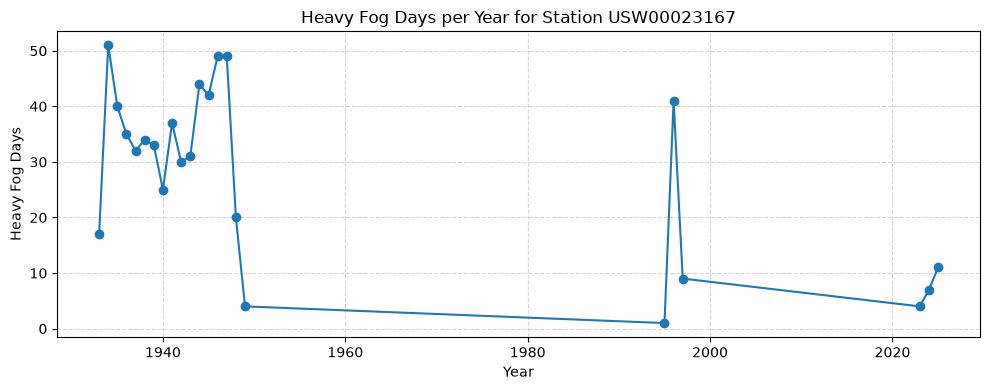

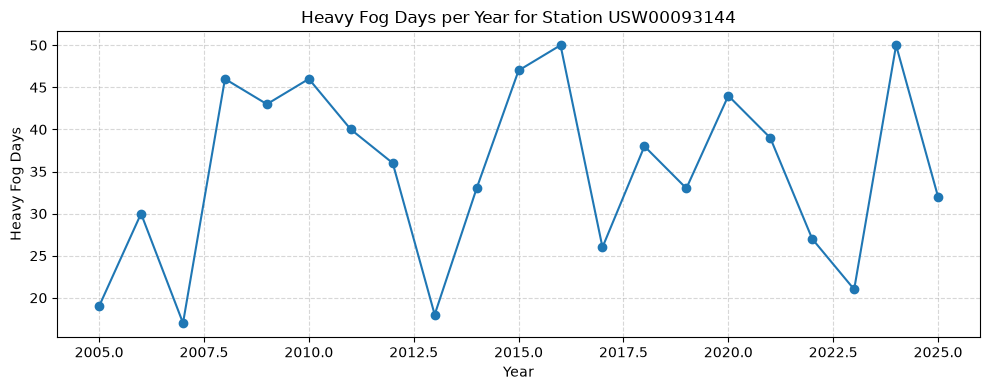

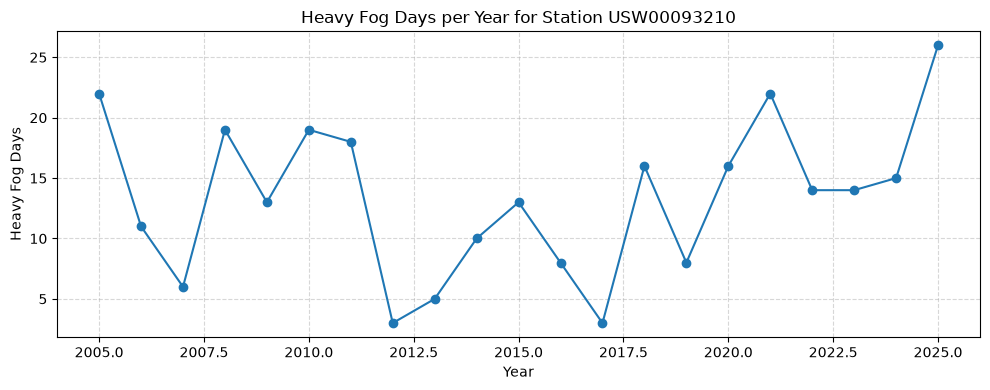

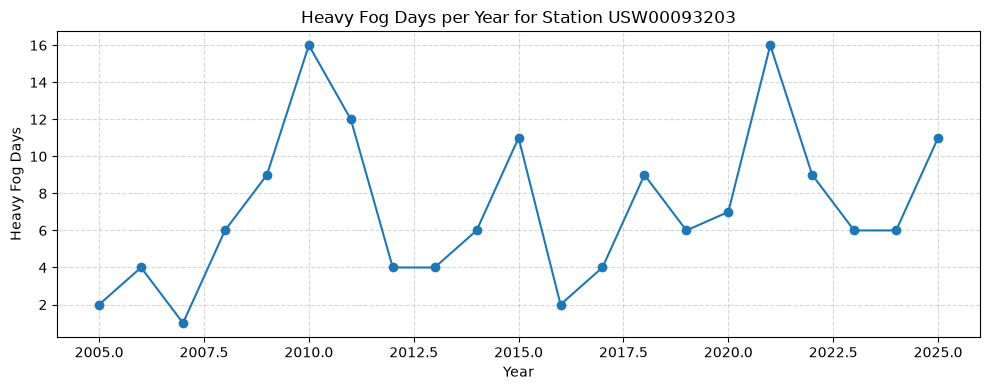

In [21]:
heavy_fog_days_year = (
    CV_densefog_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'])
    .size()
    .reset_index(name='heavy_fog_days')
)

heavy_station_year_counts = heavy_fog_days_year.groupby('STATION')['year'].nunique()
heavy_long_term_stations = heavy_station_year_counts[heavy_station_year_counts > 20].sort_values(ascending=False).index

for station in heavy_long_term_stations:
    station_df = heavy_fog_days_year[heavy_fog_days_year['STATION'] == station].sort_values('year')
    plt.figure(figsize=(10, 4))
    plt.plot(station_df['year'], station_df['heavy_fog_days'], marker='o', linestyle='-')
    plt.title(f'Heavy Fog Days per Year for Station {station}')
    plt.xlabel('Year')
    plt.ylabel('Heavy Fog Days')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()